# PROMISE12 BAMF/AIMI Colab Notebook

This notebook mirrors the practical PROMISE12 test-set inference/evaluation workflow but uses the **official BAMF/AIMI prostate MR pretrained pipeline** instead of the previous setup.

What it does:
- downloads the BAMF/AIMI repository and official pretrained weights,
- downloads the PROMISE12 test set from a direct link,
- prepares standardized NIfTI inputs,
- runs BAMF/AIMI inference in NIfTI mode via the released nnU-Net v1 weights,
- computes Dice score per case,
- saves per-case and summary CSV files,
- optionally generates a few qualitative PNG figures.

This notebook starts with a 2-case smoke test (`Case00`, `Case01`). After that, set `SMOKE_TEST = False` to run all matched PROMISE12 cases.

In [1]:
from __future__ import annotations

import json
import os
import pickle
import random
import shutil
import subprocess
import sys
import tarfile
import zipfile
from pathlib import Path

ROOT = Path('/content')
REPO_PATH = ROOT / 'aimi-prostate-mr'
DATA_ROOT = ROOT / 'data'
DOWNLOADS_DIR = DATA_ROOT / 'downloads'
EXTRACTED_DIR = DATA_ROOT / 'extracted'
STANDARDIZED_DIR = DATA_ROOT / 'standardized'
STANDARDIZED_IMAGES_DIR = STANDARDIZED_DIR / 'images'
STANDARDIZED_LABELS_DIR = STANDARDIZED_DIR / 'labels'
NNUNET_INPUT_DIR = ROOT / 'nnunet_in' / 'imagesTs'
RESULTS_PATH = ROOT / 'results'
PREDICTIONS_PATH = RESULTS_PATH / 'predictions'
METRICS_PATH = RESULTS_PATH / 'metrics'
FIGURES_PATH = RESULTS_PATH / 'figures'

PROMISE12_DOWNLOAD_URL = 'https://zenodo.org/records/8026660/files/test_data.zip?download=1'
BAMF_MODEL_URL = 'https://zenodo.org/records/8290093/files/Task788_Prostate.zip?download=1'
PROMISE12_ARCHIVE_PATH = DOWNLOADS_DIR / 'promise12_test_dataset_archive.zip'
BAMF_MODEL_ARCHIVE_PATH = DOWNLOADS_DIR / 'Task788_Prostate.zip'

SMOKE_TEST = False
SMOKE_TEST_CASES = ['Case00', 'Case01']
SEED = 42

random.seed(SEED)

for p in [
    DOWNLOADS_DIR, EXTRACTED_DIR, STANDARDIZED_IMAGES_DIR, STANDARDIZED_LABELS_DIR,
    NNUNET_INPUT_DIR, RESULTS_PATH, PREDICTIONS_PATH, METRICS_PATH, FIGURES_PATH,
]:
    p.mkdir(parents=True, exist_ok=True)

print('ROOT =', ROOT)
print('PROMISE12_DOWNLOAD_URL =', PROMISE12_DOWNLOAD_URL)
print('BAMF_MODEL_URL =', BAMF_MODEL_URL)
print('SMOKE_TEST =', SMOKE_TEST)

ROOT = /content
PROMISE12_DOWNLOAD_URL = https://zenodo.org/records/8026660/files/test_data.zip?download=1
BAMF_MODEL_URL = https://zenodo.org/records/8290093/files/Task788_Prostate.zip?download=1
SMOKE_TEST = False


In [2]:
!pip -q install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121
!pip -q install nnunet==1.7.1 SimpleITK nibabel numpy pandas matplotlib scipy tqdm seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 802.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 94.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 79.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 60.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 54.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 117.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 966.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import importlib.metadata as md
import nibabel as nib
import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt

print('Python:', sys.version.split()[0])
print('nnU-Net:', md.version('nnunet'))
print('nibabel:', nib.__version__)
print('numpy:', np.__version__)
print('pandas:', pd.__version__)
print('SimpleITK:', sitk.Version_VersionString())

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['image.cmap'] = 'gray'

Python: 3.12.13
nnU-Net: 1.7.1
nibabel: 5.4.2
numpy: 2.0.2
pandas: 2.2.2
SimpleITK: 2.5.3


In [4]:
if REPO_PATH.exists():
    print(f'Removing existing repo at {REPO_PATH}')
    shutil.rmtree(REPO_PATH)

subprocess.run(['git', 'clone', 'https://github.com/bamf-health/aimi-prostate-mr.git', str(REPO_PATH)], check=True)

readme_path = REPO_PATH / 'README.md'
print('Cloned repo:', REPO_PATH)
print('\nREADME preview:')
print('\n'.join(readme_path.read_text(encoding='utf-8').splitlines()[:40]))

Cloned repo: /content/aimi-prostate-mr

README preview:
# AIMI Annotations Initiative - Prostate MRI Segmentation

## Overview

This AIMI Annotations initiative task was to provide automated segmentation of the prostate from T2 MRI scans for the [ProstateX](https://wiki.cancerimagingarchive.net/pages/viewpage.action?pageId=23691656) collection in the [NCI Imaging Data Commons](https://portal.imaging.datacommons.cancer.gov/) (IDC). ProstateX was originally an AI challenge, this project's goal was to use an [nnUNet](https://github.com/MIC-DKFZ/nnUNet/tree/nnunetv1) model where the input and output of the model are dicom to support the [IDC's](https://portal.imaging.datacommons.cancer.gov/) goal of standardizing and searchable public radiology datasets.

The [model_performance](model_performance.ipynb) notebook contains the code to evaluate the model performance on ProstateX and other datasets.

## Training Dataset

Four different prostate datasets were used to train a prostate segmentati

In [5]:
if PROMISE12_ARCHIVE_PATH.exists():
    PROMISE12_ARCHIVE_PATH.unlink()

cmd = f'''
set -e
curl -L "{PROMISE12_DOWNLOAD_URL}" -o "{PROMISE12_ARCHIVE_PATH}" || wget -O "{PROMISE12_ARCHIVE_PATH}" "{PROMISE12_DOWNLOAD_URL}"
'''
subprocess.run(['bash', '-lc', cmd], check=True)

if EXTRACTED_DIR.exists():
    shutil.rmtree(EXTRACTED_DIR)
EXTRACTED_DIR.mkdir(parents=True, exist_ok=True)

if zipfile.is_zipfile(PROMISE12_ARCHIVE_PATH):
    with zipfile.ZipFile(PROMISE12_ARCHIVE_PATH, 'r') as zf:
        zf.extractall(EXTRACTED_DIR)
elif str(PROMISE12_ARCHIVE_PATH).endswith(('.tar.gz', '.tgz')) or tarfile.is_tarfile(PROMISE12_ARCHIVE_PATH):
    with tarfile.open(PROMISE12_ARCHIVE_PATH, 'r:*') as tf:
        tf.extractall(EXTRACTED_DIR)
else:
    raise RuntimeError(f'Unsupported archive type: {PROMISE12_ARCHIVE_PATH}')

print('PROMISE12 archive downloaded to:', PROMISE12_ARCHIVE_PATH)
print('Extraction complete:', EXTRACTED_DIR)
print(subprocess.check_output(['bash', '-lc', f'tree -L 3 "{EXTRACTED_DIR}" | head -200']).decode())

PROMISE12 archive downloaded to: /content/data/downloads/promise12_test_dataset_archive.zip
Extraction complete: /content/data/extracted



In [6]:
SUPPORTED_SUFFIXES = ('.mhd', '.mha', '.nii', '.nii.gz', '.nrrd')
LABEL_KEYWORDS = ('segmentation', 'label', 'labels', 'mask', 'gt', 'truth')


def strip_known_suffix(path: Path) -> str:
    name = path.name
    for suffix in ['.nii.gz', '.nii', '.mhd', '.mha', '.nrrd']:
        if name.lower().endswith(suffix):
            return name[:-len(suffix)]
    return path.stem


def normalize_case_token(path: Path) -> str:
    token = strip_known_suffix(path).lower()
    for word in LABEL_KEYWORDS:
        token = token.replace(word, '')
    token = token.replace('__', '_').replace('--', '-')
    token = token.strip(' _-')
    return token


def is_label_file(path: Path) -> bool:
    lower = path.name.lower()
    return any(keyword in lower for keyword in LABEL_KEYWORDS)


all_files = []
for suffix in SUPPORTED_SUFFIXES:
    all_files.extend(EXTRACTED_DIR.rglob(f'*{suffix}'))
all_files = sorted(set([p for p in all_files if p.is_file()]))

image_candidates = [p for p in all_files if not is_label_file(p)]
label_candidates = [p for p in all_files if is_label_file(p)]

print('Total supported files:', len(all_files))
print('Image candidates:', len(image_candidates))
print('Label candidates:', len(label_candidates))
print('\nSample image candidates:')
for p in image_candidates[:20]:
    print(' ', p)
print('\nSample label candidates:')
for p in label_candidates[:20]:
    print(' ', p)

if not all_files:
    raise RuntimeError('No supported image files were found in the extracted PROMISE12 archive.')

Total supported files: 60
Image candidates: 30
Label candidates: 30

Sample image candidates:
  /content/data/extracted/Case00.mhd
  /content/data/extracted/Case01.mhd
  /content/data/extracted/Case02.mhd
  /content/data/extracted/Case03.mhd
  /content/data/extracted/Case04.mhd
  /content/data/extracted/Case05.mhd
  /content/data/extracted/Case06.mhd
  /content/data/extracted/Case07.mhd
  /content/data/extracted/Case08.mhd
  /content/data/extracted/Case09.mhd
  /content/data/extracted/Case10.mhd
  /content/data/extracted/Case11.mhd
  /content/data/extracted/Case12.mhd
  /content/data/extracted/Case13.mhd
  /content/data/extracted/Case14.mhd
  /content/data/extracted/Case15.mhd
  /content/data/extracted/Case16.mhd
  /content/data/extracted/Case17.mhd
  /content/data/extracted/Case18.mhd
  /content/data/extracted/Case19.mhd

Sample label candidates:
  /content/data/extracted/Case00_segmentation.mhd
  /content/data/extracted/Case01_segmentation.mhd
  /content/data/extracted/Case02_segment

In [7]:
from dataclasses import dataclass

@dataclass
class CasePair:
    case_id: str
    image_path: Path
    label_path: Path


def match_image_and_label_files(image_files, label_files):
    label_map = {}
    for label in label_files:
        label_map.setdefault(normalize_case_token(label), []).append(label)

    matched = []
    for image in image_files:
        token = normalize_case_token(image)
        possible = label_map.get(token, [])
        if len(possible) == 1:
            matched.append(CasePair(token, image, possible[0]))
        elif len(possible) > 1:
            same_dir = [p for p in possible if p.parent == image.parent]
            chosen = sorted(same_dir or possible, key=lambda p: len(p.name))[0]
            matched.append(CasePair(token, image, chosen))

    unique = {m.case_id: m for m in matched}
    pairs = [unique[k] for k in sorted(unique.keys())]
    if not pairs:
        raise RuntimeError('No image/label pairs were matched. Inspect the extracted tree and naming conventions.')
    return pairs


def convert_to_nifti(src_path: Path, dst_path: Path, is_label=False):
    img = sitk.ReadImage(str(src_path))
    if is_label:
        arr = sitk.GetArrayFromImage(img)
        arr = (arr > 0).astype(np.uint8)
        fixed = sitk.GetImageFromArray(arr)
        fixed.CopyInformation(img)
        img = fixed
    sitk.WriteImage(img, str(dst_path), useCompression=True)


def spacing_tuple(img):
    return tuple(float(x) for x in img.GetSpacing())


case_pairs = match_image_and_label_files(image_candidates, label_candidates)

print('Matched case IDs:')
for p in case_pairs[:20]:
    print(' ', p.case_id)

selected_cases = [p.case_id for p in case_pairs]
print(f'\nUsing all discovered cases: {len(selected_cases)}')

case_pairs = [p for p in case_pairs if p.case_id in selected_cases]

if not case_pairs:
    raise RuntimeError('No selected cases were found after applying the full-run filter.')

for folder in [STANDARDIZED_IMAGES_DIR, STANDARDIZED_LABELS_DIR, NNUNET_INPUT_DIR, PREDICTIONS_PATH]:
    if folder.exists():
        shutil.rmtree(folder)
    folder.mkdir(parents=True, exist_ok=True)

records = []
issues = []
for pair in case_pairs:
    img_dst = STANDARDIZED_IMAGES_DIR / f'{pair.case_id}.nii.gz'
    lbl_dst = STANDARDIZED_LABELS_DIR / f'{pair.case_id}.nii.gz'
    convert_to_nifti(pair.image_path, img_dst, is_label=False)
    convert_to_nifti(pair.label_path, lbl_dst, is_label=True)

    img = sitk.ReadImage(str(img_dst))
    lbl = sitk.ReadImage(str(lbl_dst))
    if img.GetSize() != lbl.GetSize():
        issues.append(f'Shape mismatch for {pair.case_id}: {img.GetSize()} vs {lbl.GetSize()}')
    if spacing_tuple(img) != spacing_tuple(lbl):
        issues.append(f'Spacing mismatch for {pair.case_id}: {spacing_tuple(img)} vs {spacing_tuple(lbl)}')

    nnunet_input_path = NNUNET_INPUT_DIR / f'{pair.case_id}_0000.nii.gz'
    shutil.copy2(img_dst, nnunet_input_path)

    records.append({
        'case': pair.case_id,
        'image_src': str(pair.image_path),
        'label_src': str(pair.label_path),
        'image_nii': str(img_dst),
        'label_nii': str(lbl_dst),
        'nnunet_input': str(nnunet_input_path),
    })

prep_df = pd.DataFrame(records)
display(prep_df)

if issues:
    raise RuntimeError('Sanity check failed:\n' + '\n'.join(issues[:20]))

print('Prepared cases:', len(prep_df))


Matched case IDs:
  case00
  case01
  case02
  case03
  case04
  case05
  case06
  case07
  case08
  case09
  case10
  case11
  case12
  case13
  case14
  case15
  case16
  case17
  case18
  case19

Using all discovered cases: 30


,case,image_src,label_src,image_nii,label_nii,nnunet_input
0,case00,/content/data/extracted/Case00.mhd,/content/data/extracted/Case00_segmentation.mhd,/content/data/standardized/images/case00.nii.gz,/content/data/standardized/labels/case00.nii.gz,/content/nnunet_in/imagesTs/case00_0000.nii.gz
1,case01,/content/data/extracted/Case01.mhd,/content/data/extracted/Case01_segmentation.mhd,/content/data/standardized/images/case01.nii.gz,/content/data/standardized/labels/case01.nii.gz,/content/nnunet_in/imagesTs/case01_0000.nii.gz
2,case02,/content/data/extracted/Case02.mhd,/content/data/extracted/Case02_segmentation.mhd,/content/data/standardized/images/case02.nii.gz,/content/data/standardized/labels/case02.nii.gz,/content/nnunet_in/imagesTs/case02_0000.nii.gz
3,case03,/content/data/extracted/Case03.mhd,/content/data/extracted/Case03_segmentation.mhd,/content/data/standardized/images/case03.nii.gz,/content/data/standardized/labels/case03.nii.gz,/content/nnunet_in/imagesTs/case03_0000.nii.gz
4,case04,/content/data/extracted/Case04.mhd,/content/data/extracted/Case04_segmentation.mhd,/content/data/standardized/images/case04.nii.gz,/content/data/standardized/labels/case04.nii.gz,/content/nnunet_in/imagesTs/case04_0000.nii.gz
5,case05,/content/data/extracted/Case05.mhd,/content/data/extracted/Case05_segmentation.mhd,/content/data/standardized/images/case05.nii.gz,/content/data/standardized/labels/case05.nii.gz,/content/nnunet_in/imagesTs/case05_0000.nii.gz
6,case06,/content/data/extracted/Case06.mhd,/content/data/extracted/Case06_segmentation.mhd,/content/data/standardized/images/case06.nii.gz,/content/data/standardized/labels/case06.nii.gz,/content/nnunet_in/imagesTs/case06_0000.nii.gz
7,case07,/content/data/extracted/Case07.mhd,/content/data/extracted/Case07_segmentation.mhd,/content/data/standardized/images/case07.nii.gz,/content/data/standardized/labels/case07.nii.gz,/content/nnunet_in/imagesTs/case07_0000.nii.gz
8,case08,/content/data/extracted/Case08.mhd,/content/data/extracted/Case08_segmentation.mhd,/content/data/standardized/images/case08.nii.gz,/content/data/standardized/labels/case08.nii.gz,/content/nnunet_in/imagesTs/case08_0000.nii.gz
9,case09,/content/data/extracted/Case09.mhd,/content/data/extracted/Case09_segmentation.mhd,/content/data/standardized/images/case09.nii.gz,/content/data/standardized/labels/case09.nii.gz,/content/nnunet_in/imagesTs/case09_0000.nii.gz


Prepared cases: 30


In [8]:
os.environ['nnUNet_raw_data_base'] = str(ROOT / 'nnUNet_raw_data_base')
os.environ['nnUNet_preprocessed'] = str(ROOT / 'nnUNet_preprocessed')
os.environ['RESULTS_FOLDER'] = str(ROOT / 'nnUNet_results')

for key in ['nnUNet_raw_data_base', 'nnUNet_preprocessed', 'RESULTS_FOLDER']:
    Path(os.environ[key]).mkdir(parents=True, exist_ok=True)
    print(f'{key} = {os.environ[key]}')

if BAMF_MODEL_ARCHIVE_PATH.exists():
    BAMF_MODEL_ARCHIVE_PATH.unlink()

cmd = f'''
set -e
curl -L "{BAMF_MODEL_URL}" -o "{BAMF_MODEL_ARCHIVE_PATH}" || wget -O "{BAMF_MODEL_ARCHIVE_PATH}" "{BAMF_MODEL_URL}"
'''
subprocess.run(['bash', '-lc', cmd], check=True)

if not zipfile.is_zipfile(BAMF_MODEL_ARCHIVE_PATH):
    raise RuntimeError('Downloaded BAMF model file is not a valid ZIP archive.')

subprocess.run(['nnUNet_install_pretrained_model_from_zip', str(BAMF_MODEL_ARCHIVE_PATH)], check=True)

installed_tasks = sorted((Path(os.environ['RESULTS_FOLDER']) / 'nnUNet' / '3d_fullres').glob('Task*'))
if not installed_tasks:
    raise RuntimeError('No BAMF nnU-Net task was installed under RESULTS_FOLDER/nnUNet/3d_fullres')
MODEL_TASK_NAME = installed_tasks[0].name

plans_candidates = sorted(installed_tasks[0].rglob('plans*.pkl'))
if not plans_candidates:
    raise RuntimeError('Could not find a plans file for the installed BAMF model.')
with open(plans_candidates[0], 'rb') as f:
    plans = pickle.load(f)
expected_modalities = plans.get('num_modalities')
if expected_modalities is None and isinstance(plans.get('modalities'), dict):
    expected_modalities = len(plans['modalities'])

print('Installed BAMF task:', MODEL_TASK_NAME)
print('Plans file:', plans_candidates[0])
print('Expected modalities:', expected_modalities)

if expected_modalities != 1:
    raise RuntimeError(f'Installed BAMF model expects {expected_modalities} modalities, but PROMISE12 is single-modality T2 MRI.')

nnUNet_raw_data_base = /content/nnUNet_raw_data_base
nnUNet_preprocessed = /content/nnUNet_preprocessed
RESULTS_FOLDER = /content/nnUNet_results
Installed BAMF task: Task788_ProstateX
Plans file: /content/nnUNet_results/nnUNet/3d_fullres/Task788_ProstateX/nnUNetTrainerV2__nnUNetPlansv2.1/plans.pkl
Expected modalities: 1


In [9]:
import subprocess

print("Running BAMF/AIMI inference...")
predict_cmd = [
    "nnUNet_predict",
    "-i", str(NNUNET_INPUT_DIR),
    "-o", str(PREDICTIONS_PATH),
    "-t", MODEL_TASK_NAME,
    "-m", "3d_fullres",
    "-f", "0", "1", "2", "3", "4",
]

print(" ".join(predict_cmd))

completed = subprocess.run(
    predict_cmd,
    text=True,
    capture_output=True,
    check=False,
)

print("\nSTDOUT:\n")
print(completed.stdout)

print("\nSTDERR:\n")
print(completed.stderr)

print("\nReturn code:", completed.returncode)

if completed.returncode != 0:
    raise RuntimeError("nnUNet_predict failed. Read STDERR above.")


Running BAMF/AIMI inference...
nnUNet_predict -i /content/nnunet_in/imagesTs -o /content/results/predictions -t Task788_ProstateX -m 3d_fullres -f 0 1 2 3 4

STDOUT:



Please cite the following paper when using nnUNet:

Isensee, F., Jaeger, P.F., Kohl, S.A.A. et al. "nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation." Nat Methods (2020). https://doi.org/10.1038/s41592-020-01008-z


If you have questions or suggestions, feel free to open an issue at https://github.com/MIC-DKFZ/nnUNet

using model stored in  /content/nnUNet_results/nnUNet/3d_fullres/Task788_ProstateX/nnUNetTrainerV2__nnUNetPlansv2.1
This model expects 1 input modalities for each image
Found 30 unique case ids, here are some examples: ['case17' 'case28' 'case08' 'case10' 'case11' 'case22' 'case04' 'case28'
 'case22' 'case17']
If they don't look right, make sure to double check your filenames. They must end with _0000.nii.gz etc
number of cases: 30
number of cases that still need to 

In [10]:
def ensure_same_grid_as_gt(pred_img: sitk.Image, gt_img: sitk.Image) -> sitk.Image:
    same_size = pred_img.GetSize() == gt_img.GetSize()
    same_spacing = np.allclose(pred_img.GetSpacing(), gt_img.GetSpacing())
    same_origin = np.allclose(pred_img.GetOrigin(), gt_img.GetOrigin())
    same_direction = np.allclose(pred_img.GetDirection(), gt_img.GetDirection())
    if same_size and same_spacing and same_origin and same_direction:
        return pred_img
    return sitk.Resample(
        pred_img,
        gt_img,
        sitk.Transform(),
        sitk.sitkNearestNeighbor,
        0,
        pred_img.GetPixelID(),
    )


def binary_dice(pred_array, gt_array):
    pred_bin = pred_array > 0
    gt_bin = gt_array > 0
    pred_sum = int(pred_bin.sum())
    gt_sum = int(gt_bin.sum())
    if pred_sum == 0 and gt_sum == 0:
        return 1.0
    if pred_sum + gt_sum == 0:
        return 0.0
    intersection = int(np.logical_and(pred_bin, gt_bin).sum())
    return (2.0 * intersection) / (pred_sum + gt_sum)

rows = []
for case_id in prep_df['case']:
    pred_path = PREDICTIONS_PATH / f'{case_id}.nii.gz'
    gt_path = STANDARDIZED_LABELS_DIR / f'{case_id}.nii.gz'
    if not pred_path.exists():
        print(f'WARNING: Missing prediction for {case_id}')
        continue
    pred_img = sitk.ReadImage(str(pred_path))
    gt_img = sitk.ReadImage(str(gt_path))
    pred_img = ensure_same_grid_as_gt(pred_img, gt_img)
    pred_arr = sitk.GetArrayFromImage(pred_img)
    gt_arr = sitk.GetArrayFromImage(gt_img)
    rows.append({
        'case': case_id,
        'model': 'BAMF/AIMI prostate MR',
        'whole_gland_dice': binary_dice(pred_arr, gt_arr),
    })

results_df = pd.DataFrame(rows).sort_values('case').reset_index(drop=True)
if results_df.empty:
    raise RuntimeError('No Dice scores were computed. Check inference outputs and labels.')

display(results_df)

,case,model,whole_gland_dice
0,case00,BAMF/AIMI prostate MR,0.962086
1,case01,BAMF/AIMI prostate MR,0.912189
2,case02,BAMF/AIMI prostate MR,0.944544
3,case03,BAMF/AIMI prostate MR,0.959940
4,case04,BAMF/AIMI prostate MR,0.939306
5,case05,BAMF/AIMI prostate MR,0.922446
6,case06,BAMF/AIMI prostate MR,0.919273
7,case07,BAMF/AIMI prostate MR,0.872308
8,case08,BAMF/AIMI prostate MR,0.912359
9,case09,BAMF/AIMI prostate MR,0.852397


In [11]:
summary_df = pd.DataFrame([{
    'dataset': 'PROMISE12',
    'model': 'BAMF/AIMI prostate MR',
    'num_evaluated_cases': int(len(results_df)),
    'mean_dice': float(results_df['whole_gland_dice'].mean()),
    'std_dice': float(results_df['whole_gland_dice'].std(ddof=1)) if len(results_df) > 1 else 0.0,
    'min_dice': float(results_df['whole_gland_dice'].min()),
    'max_dice': float(results_df['whole_gland_dice'].max()),
}])

per_case_csv = METRICS_PATH / 'per_case_dice_scores.csv'
summary_csv = METRICS_PATH / 'summary_metrics.csv'
latex_table = METRICS_PATH / 'quantitative_results_table.tex'

results_df.to_csv(per_case_csv, index=False)
summary_df.to_csv(summary_csv, index=False)

latex_lines = [
    r'\begin{table}[ht]',
    r'\centering',
    r'\caption{PROMISE12 Dice scores for BAMF/AIMI prostate MR.}',
    r'\begin{tabular}{lll}',
    r'\toprule',
    r'Case & Model & Whole Gland Dice \\',
    r'\midrule',
]
for _, row in results_df.iterrows():
    latex_lines.append(f"{row['case']} & {row['model']} & {row['whole_gland_dice']:.4f} \\")
latex_lines.extend([
    r'\midrule',
    f"Dataset mean & BAMF/AIMI prostate MR & {summary_df.iloc[0]['mean_dice']:.4f} \\",
    r'\bottomrule',
    r'\end{tabular}',
    r'\end{table}',
])
latex_table.write_text('\n'.join(latex_lines))

print('Saved metrics:')
print(' ', per_case_csv)
print(' ', summary_csv)
print(' ', latex_table)
display(summary_df)


Saved metrics:
  /content/results/metrics/per_case_dice_scores.csv
  /content/results/metrics/summary_metrics.csv
  /content/results/metrics/quantitative_results_table.tex


,dataset,model,num_evaluated_cases,mean_dice,std_dice,min_dice,max_dice
0,PROMISE12,BAMF/AIMI prostate MR,30,0.916301,0.027297,0.852397,0.962086


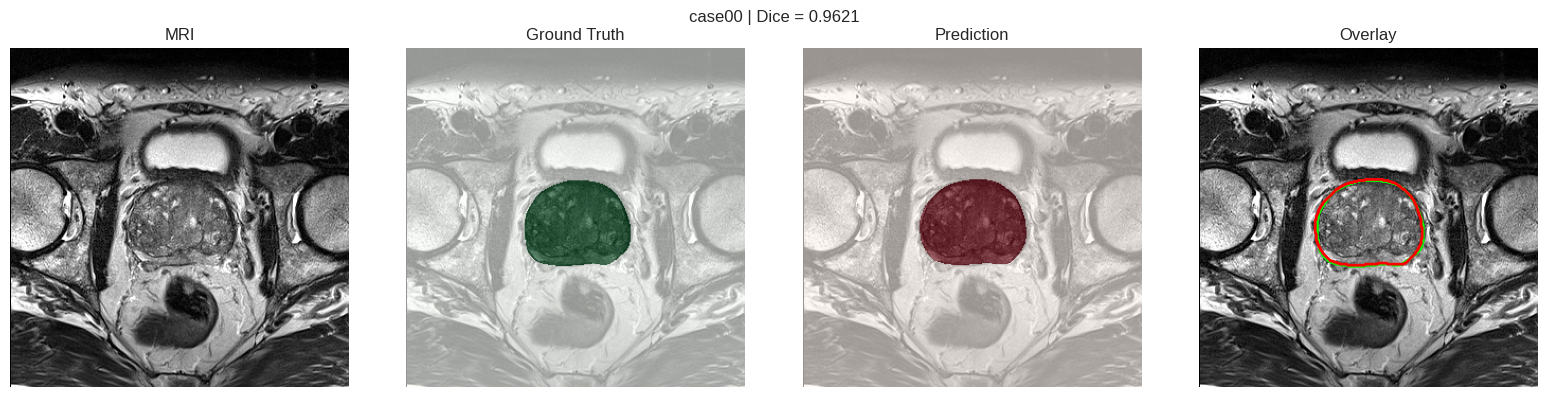

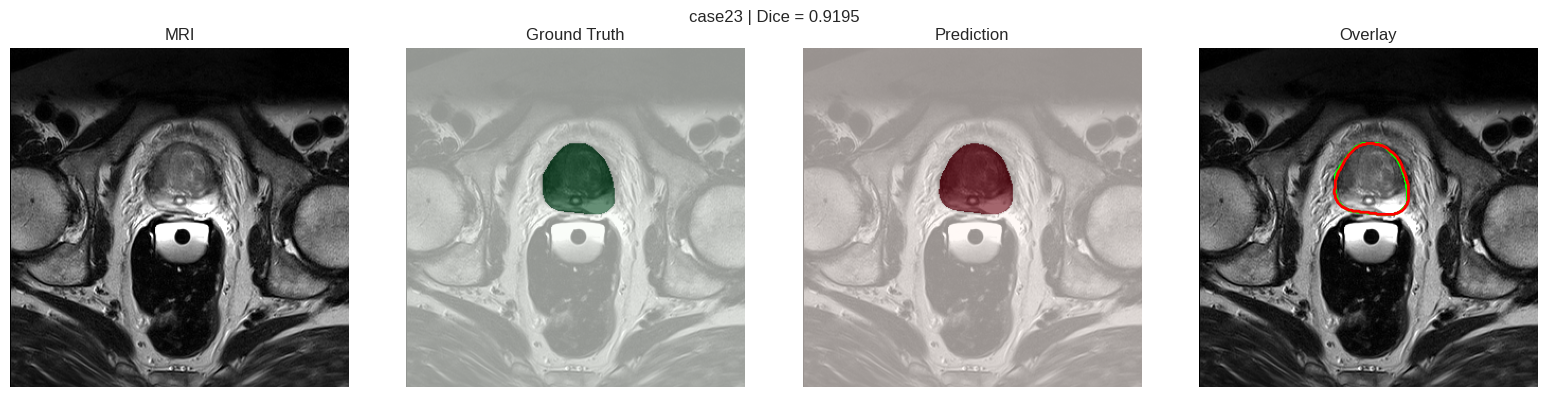

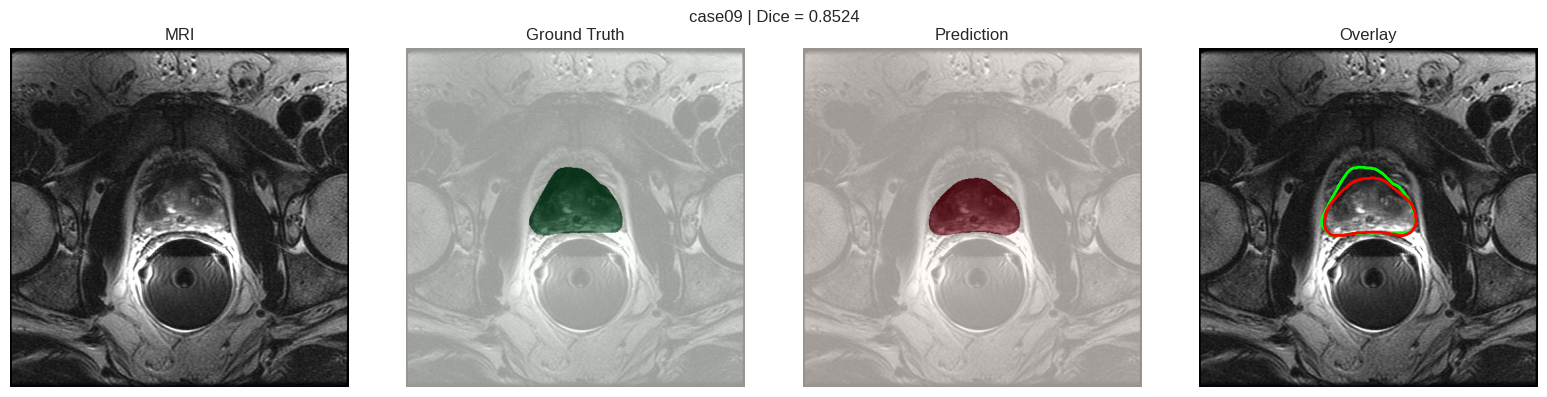

Saved figures:
  /content/results/figures/case00_compare.png
  /content/results/figures/case23_compare.png
  /content/results/figures/case09_compare.png


In [12]:
def pick_slice_index(gt_arr, pred_arr):
    combined = (gt_arr > 0) | (pred_arr > 0)
    per_slice = combined.reshape(combined.shape[0], -1).sum(axis=1)
    if per_slice.max() == 0:
        return combined.shape[0] // 2
    return int(np.argmax(per_slice))


def select_representative_cases(df):
    df_sorted = df.sort_values('whole_gland_dice').reset_index(drop=True)
    n = len(df_sorted)
    chosen = []
    for idx in [n - 1, n // 2, 0]:
        case_id = df_sorted.iloc[idx]['case']
        if case_id not in chosen:
            chosen.append(case_id)
    return chosen


def save_case_figure(case_id):
    image_path = STANDARDIZED_IMAGES_DIR / f'{case_id}.nii.gz'
    gt_path = STANDARDIZED_LABELS_DIR / f'{case_id}.nii.gz'
    pred_path = PREDICTIONS_PATH / f'{case_id}.nii.gz'

    image_img = sitk.ReadImage(str(image_path))
    gt_img = sitk.ReadImage(str(gt_path))
    pred_img = ensure_same_grid_as_gt(sitk.ReadImage(str(pred_path)), gt_img)

    image_arr = sitk.GetArrayFromImage(image_img)
    gt_arr = sitk.GetArrayFromImage(gt_img) > 0
    pred_arr = sitk.GetArrayFromImage(pred_img) > 0

    slice_idx = pick_slice_index(gt_arr, pred_arr)
    img_slice = image_arr[slice_idx]
    gt_slice = gt_arr[slice_idx]
    pred_slice = pred_arr[slice_idx]

    vmin = np.percentile(img_slice, 1)
    vmax = np.percentile(img_slice, 99)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img_slice, cmap='gray', vmin=vmin, vmax=vmax)
    axes[0].set_title('MRI')
    axes[1].imshow(img_slice, cmap='gray', vmin=vmin, vmax=vmax)
    axes[1].imshow(gt_slice, alpha=0.6, cmap='Greens')
    axes[1].set_title('Ground Truth')
    axes[2].imshow(img_slice, cmap='gray', vmin=vmin, vmax=vmax)
    axes[2].imshow(pred_slice, alpha=0.6, cmap='Reds')
    axes[2].set_title('Prediction')
    axes[3].imshow(img_slice, cmap='gray', vmin=vmin, vmax=vmax)
    if gt_slice.any():
        axes[3].contour(gt_slice.astype(np.uint8), levels=[0.5], colors='lime', linewidths=2)
    if pred_slice.any():
        axes[3].contour(pred_slice.astype(np.uint8), levels=[0.5], colors='red', linewidths=2)
    axes[3].set_title('Overlay')
    for ax in axes:
        ax.axis('off')

    dice = float(results_df.loc[results_df['case'] == case_id, 'whole_gland_dice'].iloc[0])
    fig.suptitle(f'{case_id} | Dice = {dice:.4f}')
    out_path = FIGURES_PATH / f'{case_id}_compare.png'
    fig.tight_layout()
    fig.savefig(out_path, dpi=220, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return out_path

selected_figure_cases = select_representative_cases(results_df)
saved_figures = [save_case_figure(case_id) for case_id in selected_figure_cases]
print('Saved figures:')
for p in saved_figures:
    print(' ', p)

In [13]:
summary_row = summary_df.iloc[0]
print('Final summary')
print('-------------')
print('Dataset:', summary_row['dataset'])
print('Model:', summary_row['model'])
print('Number of evaluated cases:', int(summary_row['num_evaluated_cases']))
print(f"Mean Dice: {summary_row['mean_dice']:.4f}")
print(f"Std Dice:  {summary_row['std_dice']:.4f}")
print(f"Min Dice:  {summary_row['min_dice']:.4f}")
print(f"Max Dice:  {summary_row['max_dice']:.4f}")
print('Per-case CSV:', per_case_csv)
print('Summary CSV:', summary_csv)
print('Predictions folder:', PREDICTIONS_PATH)
if saved_figures:
    print('Figures:')
    for p in saved_figures:
        print(' ', p)

Final summary
-------------
Dataset: PROMISE12
Model: BAMF/AIMI prostate MR
Number of evaluated cases: 30
Mean Dice: 0.9163
Std Dice:  0.0273
Min Dice:  0.8524
Max Dice:  0.9621
Per-case CSV: /content/results/metrics/per_case_dice_scores.csv
Summary CSV: /content/results/metrics/summary_metrics.csv
Predictions folder: /content/results/predictions
Figures:
  /content/results/figures/case00_compare.png
  /content/results/figures/case23_compare.png
  /content/results/figures/case09_compare.png
